# 07 — Random Forest Structural: Analysis

Deep-dive analysis of the trained structural Random Forest model.

**Run `05_random_forest_structural.ipynb` first** to populate `models/structural_random_forest.pkl`.

## 1. Setup — Load Model & Data

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split, GroupKFold, cross_val_predict
from sklearn.metrics import (
    roc_curve, roc_auc_score, accuracy_score,
    precision_recall_fscore_support, confusion_matrix,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN
from sklearn.base import clone

sys.path.insert(0, '../../src')
from features import STRUCTURAL_COLS, structural_features

RANDOM_STATE = 42
MODELS_DIR   = Path("../../models")

lf = pd.read_csv("../../data/train/train_login_form-2026-08.csv", sep=";")
nf = pd.read_csv("../../data/train/train_no_form-2026-08.csv", index_col=0)
if "schreenshot_path" in nf.columns:
    nf.drop(columns=["schreenshot_path"], inplace=True)
lf.dropna(subset=["html_signature"], inplace=True)
nf.dropna(subset=["html_signature"], inplace=True)
df = pd.concat([lf, nf], ignore_index=True)
df = df.drop_duplicates(subset=["html_signature"]).reset_index(drop=True)
df["binary_label"] = (df["label"] == "LOGIN_FORM_MALICIOUS").astype(int)
df = structural_features(df)
X = df[STRUCTURAL_COLS].values
y = df["binary_label"].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

model = joblib.load(MODELS_DIR / "structural_random_forest.pkl")

y_train_pred = model.predict(X_train);  y_train_prob = model.predict_proba(X_train)[:, 1]
y_test_pred  = model.predict(X_test);   y_test_prob  = model.predict_proba(X_test)[:, 1]
train_acc    = accuracy_score(y_train, y_train_pred)
test_acc     = accuracy_score(y_test,  y_test_pred)

lf_rt = pd.read_csv("../../data/retest/signed_retest_login_form.csv", index_col=0)
nf_rt = pd.read_csv("../../data/retest/signed_retest_no_form.csv",    index_col=0)
for df_ in [lf_rt, nf_rt]:
    for junk in ("Unnamed: 0", "schreenshot_path"):
        if junk in df_.columns:
            df_.drop(columns=[junk], inplace=True)
df_rt = pd.concat([lf_rt, nf_rt], ignore_index=True)
df_rt.dropna(subset=["html_signature"], inplace=True)
df_rt.reset_index(drop=True, inplace=True)
df_rt["binary_label"] = df_rt["label"].str.contains("LOGIN_FORM", case=False, na=False).astype(int)
df_rt = structural_features(df_rt)
X_rt      = df_rt[STRUCTURAL_COLS].values
y_rt      = df_rt["binary_label"].values
y_rt_pred = model.predict(X_rt);  y_rt_prob = model.predict_proba(X_rt)[:, 1]
retest_acc = accuracy_score(y_rt, y_rt_pred)

print("Model and data loaded.")

Model and data loaded.


## 2. ROC Curve

Test       AUC 95% CI: [0.947 - 0.982]
Validation AUC 95% CI: [0.877 - 0.957]


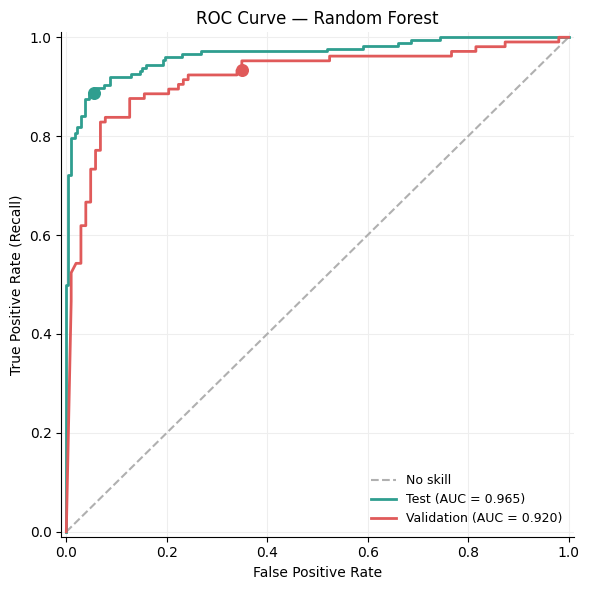

In [2]:
fpr_test, tpr_test, thr_test = roc_curve(y_test, y_test_prob)
fpr_val,  tpr_val,  thr_val  = roc_curve(y_rt,   y_rt_prob)
auc_test = roc_auc_score(y_test, y_test_prob)
auc_val  = roc_auc_score(y_rt,   y_rt_prob)

_rng = np.random.default_rng(42)

def _bootstrap_ci(score_fn, y_true, y_score, n=1000):
    vals = []
    for _ in range(n):
        idx = _rng.choice(len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) == 2:
            vals.append(score_fn(y_true[idx], y_score[idx]))
    return np.percentile(vals, [2.5, 97.5])

ci_test = _bootstrap_ci(roc_auc_score, y_test, y_test_prob)
ci_val  = _bootstrap_ci(roc_auc_score, y_rt,   y_rt_prob)

def _op_roc(fpr, tpr, thresholds, t=0.5):
    idx = np.argmin(np.abs(thresholds - t))
    return fpr[idx], tpr[idx]

op_test = _op_roc(fpr_test, tpr_test, thr_test)
op_val  = _op_roc(fpr_val,  tpr_val,  thr_val)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], linestyle='--', color='#b0b0b0', linewidth=1.5, label='No skill')
ax.plot(fpr_test, tpr_test, color='#2f9e8f', linewidth=2,
        label=f'Test (AUC = {auc_test:.3f})')
ax.scatter(*op_test, color='#2f9e8f', s=70, zorder=5, label='_nolegend_')
ax.plot(fpr_val, tpr_val, color='#e05a5a', linewidth=2,
        label=f'Validation (AUC = {auc_val:.3f})')
ax.scatter(*op_val, color='#e05a5a', s=70, zorder=5, label='_nolegend_')

print(f'Test       AUC 95% CI: [{ci_test[0]:.3f} - {ci_test[1]:.3f}]')
print(f'Validation AUC 95% CI: [{ci_val[0]:.3f} - {ci_val[1]:.3f}]')

ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve — Random Forest')
ax.grid(True, color='#eeeeee', linewidth=0.8)
ax.set_axisbelow(True)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
ax.legend(loc='lower right', frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## 3. Accuracy Summary

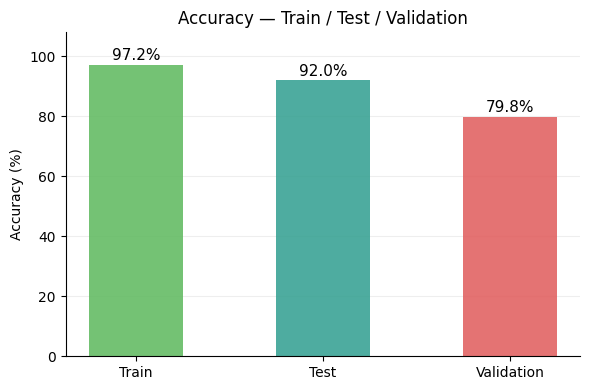

In [3]:
labels     = ['Train', 'Test', 'Validation']
accuracies = [train_acc * 100, test_acc * 100, retest_acc * 100]
bar_colors = ['#5cb85c', '#2f9e8f', '#e05a5a']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, accuracies, color=bar_colors, width=0.5, alpha=0.85)

for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=11)

ax.set_ylim(0, 108)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy — Train / Test / Validation')
ax.grid(True, axis='y', color='#eeeeee', linewidth=0.8)
ax.set_axisbelow(True)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## 4. Threshold Fine-Tuning (accuracy-optimized, leakage-safe)

In [ ]:
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN
from sklearn.base import clone

# cluster signatures into kit families so near-duplicate kits don't straddle folds
sig_vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 6), min_df=2, sublinear_tf=True)
sig_tfidf = sig_vec.fit_transform(df["html_signature"])
raw_kit = DBSCAN(eps=0.15, min_samples=2, metric="cosine").fit_predict(sig_tfidf)

# DBSCAN noise (-1): assign each singleton its own group id
kit_group = raw_kit.astype(int).copy()
next_id = int(raw_kit.max()) + 1
for i in np.where(raw_kit == -1)[0]:
    kit_group[i] = next_id
    next_id += 1
print(f"Kit families: {len({g for g in raw_kit if g != -1})}  |  "
      f"singleton (noise) groups: {int((raw_kit == -1).sum())}  |  "
      f"total groups: {len(set(kit_group))}")

_, _, _, _, groups_train, _ = train_test_split(
    X, y, kit_group, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# GroupKFold OOF probs — no kit family spans both fit and held-out portions
gkf = GroupKFold(n_splits=5)
oof_prob = cross_val_predict(
    clone(model), X_train, y_train,
    cv=gkf.split(X_train, y_train, groups_train),
    method="predict_proba", n_jobs=-1
)[:, 1]

# Sweep thresholds; pick the one maximising overall accuracy on OOF probs
grid = np.round(np.arange(0.05, 0.96, 0.01), 2)
acc_by_t = np.array([
    accuracy_score(y_train, (oof_prob >= t).astype(int))
    for t in grid
])
best_t = float(grid[acc_by_t.argmax()])
print(f"Best accuracy threshold (GroupKFold OOF): {best_t}  |  OOF accuracy = {acc_by_t.max()*100:.1f}%")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(grid, acc_by_t, color="#5cb85c", linewidth=2)
ax.axvline(best_t, color="#2f9e8f", linestyle="--", label=f"Best Accuracy {best_t}")
ax.axvline(0.5, color="#b0b0b0", linestyle="--", label="default 0.5")
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Accuracy")
ax.set_title("Threshold Tuning on GroupKFold")
ax.grid(True, color="#eeeeee", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
def eval_at(y_true, prob, t):
    """Metrics for the malicious class at a given decision threshold."""
    pred = (prob >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_true, pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {
        "Threshold": t,
        "MAL Precision": f"{p[1]*100:.1f}%", "MAL Recall": f"{r[1]*100:.1f}%",
        "MAL F1": f"{f1[1]*100:.1f}%",
        "Accuracy": f"{accuracy_score(y_true, pred)*100:.1f}%",
        "FP": int(fp), "FN": int(fn),
    }

comparison = pd.DataFrame(
    [eval_at(y_rt, y_rt_prob, 0.5), eval_at(y_rt, y_rt_prob, best_t)],
    index=["Default (0.5)", f"Tuned accuracy ({best_t})"],
)
print("Retest — default vs accuracy-tuned threshold")
display(comparison)

y_rt_pred_tuned = (y_rt_prob >= best_t).astype(int)

## 5. Label-Noise Audit of Validation False Positives

For each NO_FORM retest row with 'login' in the URL, we show the page's structure
(`has_form`/`has_input`/`input_count`) and what the model predicted:

- **Real login structure** (`has_form` **and** `has_input`) → almost certainly **mislabeled** login
  pages; the model flags them `MALICIOUS`, which shows up as a "false positive" against a wrong label.
- **No form/input** → likely **parked or taken-down** phishing URLs (the kit was removed before the
  crawl), so `NO_FORM` is arguably correct and the model rightly leaves them alone.

In [ ]:
# NO_FORM rows whose URL contains "login" — likely mislabeled
nf_mask = df_rt["binary_label"].values == 0
noform = df_rt[nf_mask].copy()
noform["mal_prob"] = y_rt_prob[nf_mask]
noform["model_pred"] = np.where(y_rt_pred[nf_mask] == 1, "MALICIOUS", "NO_FORM")

login_rows = (
    noform[noform["url"].str.contains("login", case=False, na=False)]
    .sort_values("mal_prob", ascending=False)
)

real_login = (login_rows["has_form"] == 1) & (login_rows["has_input"] == 1)
print(f"NO_FORM validation rows (signed_retest_no_form.csv) : {len(noform)}")
print(f"...with the word 'login' in the URL                 : {len(login_rows)}")
print(f"   - real login structure (form + input)           : {int(real_login.sum())}  <- likely mislabeled")
print(f"   - no form/input (parked / taken-down URL)        : {int((~real_login).sum())}\n")

view = login_rows[[
    "url", "mal_prob", "model_pred",
    "has_form", "has_input", "input_count", "signature_length",
]].copy()
view["url"] = view["url"].str.slice(0, 60)
view["mal_prob"] = view["mal_prob"].round(3)
display(view.reset_index(drop=True))

In [ ]:
from matplotlib.patches import Patch

plot_df = login_rows.sort_values("mal_prob")
is_login = ((plot_df["has_form"] == 1) & (plot_df["has_input"] == 1)).values
colors = np.where(is_login, "#5cb85c", "#b0b0b0")
labels = (plot_df["url"].str.replace(r"^https?://", "", regex=True)
                        .str.slice(0, 42)).values

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(len(plot_df)), plot_df["mal_prob"].values, color=colors)
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(labels, fontsize=9)
ax.axvline(0.5, color="#e05a5a", linestyle="--", linewidth=1.5)
ax.set_xlim(0, 1.05)
ax.set_xlabel("Model Probability")
ax.set_title("NO_FORM pages with 'login' in URL — Noise")

for i, v in enumerate(plot_df["mal_prob"].values):
    ax.text(v + 0.012, i, f"{v:.2f}", va="center", fontsize=8, color="#333333")

handles = [
    Patch(color="#5cb85c", label="has form + input  (Mislabeled)"),
    Patch(color="#b0b0b0", label="no form/input"),
    plt.Line2D([0], [0], color="#e05a5a", linestyle="--", label="Threshold 0.5"),
]
ax.legend(handles=handles, frameon=False, fontsize=8, loc="lower right")
ax.grid(True, axis="x", color="#eeeeee", linewidth=0.8)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("login_url_noform_probs_rf.png", dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved login_url_noform_probs_rf.png")

In [ ]:
from IPython.display import Image

Image(filename="login_url_noform_probs_rf.png")